# Выполнил
Трифонов Дмитрий Сергеевич, 12-25РПм, 1 курс, Программная инженерия

# Практическое занятие 3.2: Первая нейронная сеть на Keras и TensorFlow

**Цели работы:**
1. Построение и обучение модели нейронной сети Keras.
2. Освоение процесса: модель -> оптимизатор -> функция потерь -> метрики -> обучение -> оценка.
3. Работа с Fashion-MNIST.
4. Исследование влияния гиперпараметров.

### 1. Импорт библиотек и загрузка данных

In [1]:
!pip install scikit-learn

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("Train shape:", x_train.shape, "Test shape:", x_test.shape)

TensorFlow version: 2.20.0
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 18s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 4s 1us/step
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


### 2. Подготовка данных
Нормализация и создание валидационной выборки.

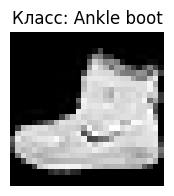

In [2]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

val_count = 5000
x_val, y_val = x_train[-val_count:], y_train[-val_count:]
x_train, y_train = x_train[:-val_count], y_train[:-val_count]

plt.figure(figsize=(2,2))
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Класс: {class_names[y_train[0]]}")
plt.axis("off")
plt.show()

### 3. Построение базовой модели Sequential

In [3]:
model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Компиляция и обучение базовой модели

In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=2
)

Epoch 1/10
430/430 - 2s - 5ms/step - accuracy: 0.8077 - loss: 0.5638 - val_accuracy: 0.8382 - val_loss: 0.4475
Epoch 2/10
430/430 - 1s - 3ms/step - accuracy: 0.8572 - loss: 0.4075 - val_accuracy: 0.8510 - val_loss: 0.4077
Epoch 3/10
430/430 - 1s - 3ms/step - accuracy: 0.8701 - loss: 0.3682 - val_accuracy: 0.8710 - val_loss: 0.3599
Epoch 4/10
430/430 - 1s - 3ms/step - accuracy: 0.8789 - loss: 0.3387 - val_accuracy: 0.8744 - val_loss: 0.3525
Epoch 5/10
430/430 - 1s - 3ms/step - accuracy: 0.8867 - loss: 0.3184 - val_accuracy: 0.8780 - val_loss: 0.3357
Epoch 6/10
430/430 - 1s - 3ms/step - accuracy: 0.8907 - loss: 0.3027 - val_accuracy: 0.8774 - val_loss: 0.3452
Epoch 7/10
430/430 - 1s - 3ms/step - accuracy: 0.8955 - loss: 0.2905 - val_accuracy: 0.8810 - val_loss: 0.3312
Epoch 8/10
430/430 - 1s - 3ms/step - accuracy: 0.8994 - loss: 0.2787 - val_accuracy: 0.8816 - val_loss: 0.3254
Epoch 9/10
430/430 - 1s - 3ms/step - accuracy: 0.9010 - loss: 0.2721 - val_accuracy: 0.8842 - val_loss: 0.3189
E

### 5. Анализ и визуализация обучения

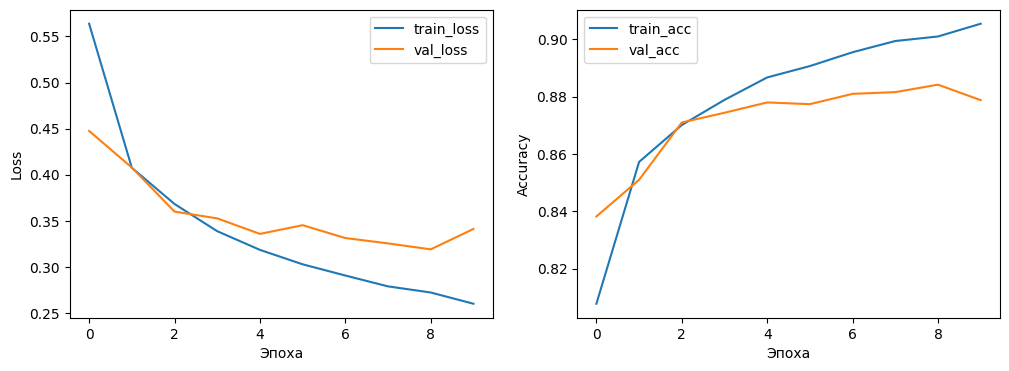

In [5]:
def plot_training_history(h):
    hist = h.history
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.xlabel("Эпоха"); plt.ylabel("Loss"); plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(hist["accuracy"], label="train_acc")
    plt.plot(hist["val_accuracy"], label="val_acc")
    plt.xlabel("Эпоха"); plt.ylabel("Accuracy"); plt.legend()
    plt.show()

plot_training_history(history)

### 6. Оценка качества и матрица ошибок

Тестовая точность: 0.8750


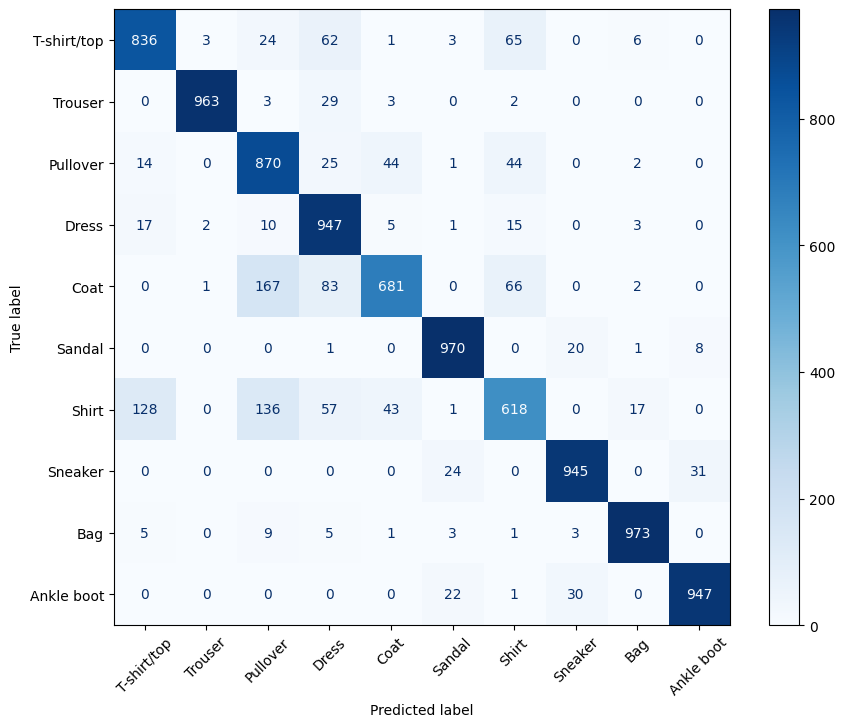

In [6]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Тестовая точность: {test_acc:.4f}")

y_pred = model.predict(x_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10,8))
disp.plot(xticks_rotation=45, cmap="Blues", ax=ax)
plt.show()

### 7. Улучшение модели: регуляризация и Dropout

In [7]:
reg_model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

reg_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
mc = ModelCheckpoint("best_fmnist.keras", monitor="val_loss", save_best_only=True)

reg_hist = reg_model.fit(
    x_train, y_train, 
    epochs=20, 
    batch_size=128, 
    validation_data=(x_val, y_val), 
    callbacks=[es, mc], 
    verbose=2
)

Epoch 1/20


C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


430/430 - 3s - 6ms/step - accuracy: 0.7773 - loss: 0.6772 - val_accuracy: 0.8498 - val_loss: 0.4650
Epoch 2/20
430/430 - 2s - 4ms/step - accuracy: 0.8409 - loss: 0.4941 - val_accuracy: 0.8642 - val_loss: 0.4185
Epoch 3/20
430/430 - 2s - 4ms/step - accuracy: 0.8553 - loss: 0.4563 - val_accuracy: 0.8690 - val_loss: 0.4055
Epoch 4/20
430/430 - 2s - 4ms/step - accuracy: 0.8621 - loss: 0.4343 - val_accuracy: 0.8772 - val_loss: 0.4015
Epoch 5/20
430/430 - 2s - 4ms/step - accuracy: 0.8670 - loss: 0.4189 - val_accuracy: 0.8706 - val_loss: 0.4101
Epoch 6/20
430/430 - 2s - 4ms/step - accuracy: 0.8716 - loss: 0.4078 - val_accuracy: 0.8750 - val_loss: 0.3863
Epoch 7/20
430/430 - 2s - 4ms/step - accuracy: 0.8739 - loss: 0.3992 - val_accuracy: 0.8786 - val_loss: 0.3904
Epoch 8/20
430/430 - 2s - 4ms/step - accuracy: 0.8763 - loss: 0.3948 - val_accuracy: 0.8782 - val_loss: 0.3834
Epoch 9/20
430/430 - 2s - 4ms/step - accuracy: 0.8778 - loss: 0.3894 - val_accuracy: 0.8804 - val_loss: 0.3795
Epoch 10/20


### 8. Сравнение моделей

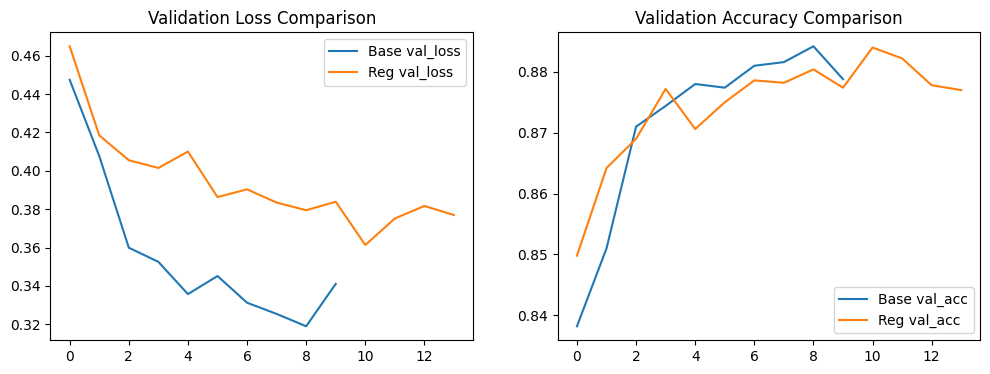

In [8]:
def compare_plots(h1, h2, name1="Base", name2="Reg"):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(h1.history['val_loss'], label=f'{name1} val_loss')
    plt.plot(h2.history['val_loss'], label=f'{name2} val_loss')
    plt.title('Validation Loss Comparison'); plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(h1.history['val_accuracy'], label=f'{name1} val_acc')
    plt.plot(h2.history['val_accuracy'], label=f'{name2} val_acc')
    plt.title('Validation Accuracy Comparison'); plt.legend()
    plt.show()

compare_plots(history, reg_hist)

### 9. Исследовательская часть (Подгруппа A: Оптимизаторы)
Сравним Adam, SGD и RMSprop.

Тестирование оптимизатора: adam
Тестирование оптимизатора: sgd
Тестирование оптимизатора: rmsprop


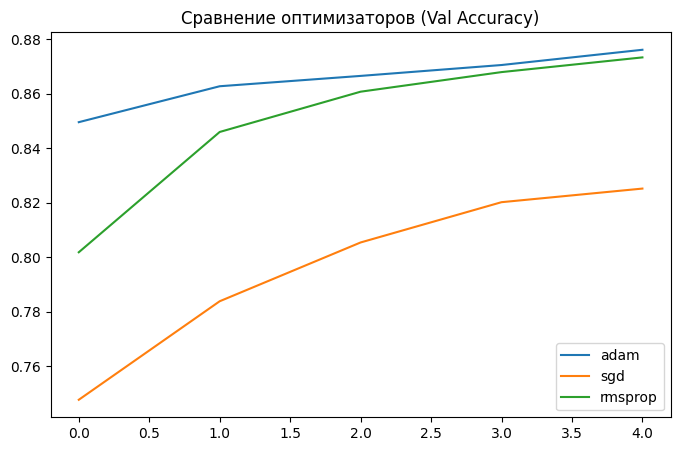

In [9]:
optimizers = ['adam', 'sgd', 'rmsprop']
results = {}

for opt in optimizers:
    print(f"Тестирование оптимизатора: {opt}")
    test_model = models.Sequential([
        layers.Flatten(input_shape=(28,28)),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    test_model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h = test_model.fit(x_train, y_train, epochs=5, batch_size=128, validation_data=(x_val, y_val), verbose=0)
    results[opt] = h

plt.figure(figsize=(8,5))
for opt in optimizers:
    plt.plot(results[opt].history['val_accuracy'], label=opt)
plt.title("Сравнение оптимизаторов (Val Accuracy)")
plt.legend(); plt.show()

### 10. Ответы на контрольные вопросы

1. **Что задаётся в compile()?** Оптимизатор (алгоритм градиентного спуска), функция потерь (метрика ошибки для обучения) и дополнительные метрики (для мониторинга пользователем). Это обязательно, чтобы сформировать граф вычислений для обратного распространения ошибки.
2. **Почему Softmax?** Она преобразует вектор выходов в вероятностное распределение (сумма = 1), где каждое значение — вероятность принадлежности объекта к конкретному классу.
3. **Как распознать переобучение?** По расхождению графиков: если Loss на обучении падает, а на валидации начинает расти.
4. **Как работают EarlyStopping и ModelCheckpoint?** EarlyStopping прерывает обучение, если val_loss не улучшается N эпох. ModelCheckpoint сохраняет веса модели с наилучшим показателем валидации.
5. **Чем отличаются Sequential и Functional API?** Sequential — это линейная стопка слоев. Functional позволяет создавать сложные архитектуры (с несколькими входами/выходами, остаточными связями).
6. **Что изменится без нормализации?** Обучение будет идти значительно медленнее, возможны числовые ошибки (взрыв градиентов) из-за больших весов на входе.

--- 
### Общий вывод:
В ходе работы была успешно построена и обучена нейронная сеть на базе Keras. Было установлено, что применение Dropout и регуляризации L2 позволяет снизить переобучение. Оптимизатор Adam показал наиболее быструю сходимость в сравнении с классическим SGD.